# ARC-LeWM: decode-by-planning JEPA, meta-trained on the ARC public train split
Spec: docs/superpowers/specs/2026-06-09-arc-lewm-design.md
LeWM methods kept verbatim: end-to-end (no EMA / no stop-grad), loss = pred MSE + 0.09*SIGReg, AdaLN predictor, inference = latent-cost optimization (no decoder).
Flagged deviation: K=16 register tokens instead of single CLS (validated by Gate L3).

In [1]:
import json, math, os, random, copy, time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange, repeat
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0); random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_HW = 30; NUM_COLORS = 10; PAD_ID = 10; VOCAB = 11
D = 192          # LeWM embed_dim
K = 16           # register tokens (flagged deviation from single CLS)
ND_MAX = 4       # max demo pairs per episode
LAM = 0.09       # LeWM sigreg weight
CKPT = Path("data/arc_lewm.pt")
print("device:", DEVICE, "| torch:", torch.__version__)

device: cuda | torch: 2.8.0+cu128


In [2]:
ARC_DIR = Path("data/arc")

def load_arc_split(split):
    """Return dict task_id -> {'train': [(in,out),...], 'test': [(in,out),...]}."""
    out = {}
    for p in sorted((ARC_DIR / "data" / split).glob("*.json")):
        d = json.loads(p.read_text())
        out[p.stem] = {
            "train": [(np.array(e["input"], np.uint8), np.array(e["output"], np.uint8)) for e in d["train"]],
            "test":  [(np.array(e["input"], np.uint8), np.array(e["output"], np.uint8)) for e in d["test"]],
        }
    return out

TRAIN_TASKS = load_arc_split("training")
EVAL_TASKS  = load_arc_split("evaluation")
assert len(TRAIN_TASKS) == 400 and len(EVAL_TASKS) == 400
print("OK: 400 train / 400 eval tasks")

OK: 400 train / 400 eval tasks


## GPU cache + episodic sampler — Gate L0

In [3]:
def pad30(g):
    c = np.full((MAX_HW, MAX_HW), PAD_ID, np.uint8)
    c[:g.shape[0], :g.shape[1]] = g
    return c

def dihedral_variants(g):
    # 8 symmetries: rot k=0..3, each plus a left-right flip
    vs = []
    for k in range(4):
        r = np.rot90(g, k)
        vs.append(r); vs.append(np.fliplr(r))
    return vs

def build_cache(tasks):
    """GPU cache: grids (N,8,30,30) uint8, shapes (N,8,2) long, idx task->pair index lists."""
    grids, shapes, idx = [], [], {}
    def add(g):
        vs = dihedral_variants(g)
        grids.append(np.stack([pad30(v) for v in vs]))
        shapes.append(np.array([v.shape for v in vs], np.int64))
        return len(grids) - 1
    for tid, t in tasks.items():
        idx[tid] = {s: [(add(i), add(o)) for i, o in t[s]] for s in ("train", "test")}
    return {"grids": torch.from_numpy(np.stack(grids)).to(DEVICE),
            "shapes": torch.from_numpy(np.stack(shapes)).to(DEVICE), "idx": idx}

t0 = time.time()
TRAIN_CACHE = build_cache(TRAIN_TASKS)
print(f"train cache: {TRAIN_CACHE['grids'].shape} in {time.time()-t0:.1f}s")

train cache: torch.Size([3436, 8, 30, 30]) in 0.2s


In [4]:
# Only tasks with >=2 train pairs can yield a held-out query
TRAIN_TIDS = [t for t in TRAIN_CACHE["idx"] if len(TRAIN_CACHE["idx"][t]["train"]) >= 2]

def sample_episodes(cache, tids, B=64, nd_max=ND_MAX, augment=True):
    """Sample B episodes: nd demos + 1 held-out query, same dihedral+color perm per episode."""
    di, do, qi, qo, dm = [], [], [], [], []
    for _ in range(B):
        pairs = cache["idx"][random.choice(tids)]["train"]
        ps = random.sample(pairs, min(len(pairs), nd_max + 1))
        (q_in, q_out), ds = ps[0], ps[1:]
        mask = [1.0] * len(ds) + [0.0] * (nd_max - len(ds))
        ds = ds + [ds[-1]] * (nd_max - len(ds))  # pad by repeating, masked out
        di.append([p[0] for p in ds]); do.append([p[1] for p in ds])
        qi.append(q_in); qo.append(q_out); dm.append(mask)
    di = torch.tensor(di, device=DEVICE); do = torch.tensor(do, device=DEVICE)
    qi = torch.tensor(qi, device=DEVICE); qo = torch.tensor(qo, device=DEVICE)
    dm = torch.tensor(dm, device=DEVICE)
    d = torch.randint(0, 8 if augment else 1, (B,), device=DEVICE)
    # color permutation table per episode; PAD stays PAD
    perm = torch.stack([torch.randperm(NUM_COLORS, device=DEVICE) if augment
                        else torch.arange(NUM_COLORS, device=DEVICE) for _ in range(B)])
    perm = torch.cat([perm, torch.full((B, 1), PAD_ID, device=DEVICE)], 1)  # (B,11)

    def fetch(ix):  # ix: (B,...) grid indices -> recolored dihedral grids
        dd = d.view(B, *([1] * (ix.dim() - 1))).expand_as(ix)
        g = cache["grids"][ix, dd].long()                       # (B,...,30,30)
        bidx = torch.arange(B, device=DEVICE).view(B, *([1] * (g.dim() - 1))).expand_as(g)
        return perm[bidx, g]  # per-episode color relabeling via advanced indexing

    ep = {"demo_in": fetch(di), "demo_out": fetch(do), "q_in": fetch(qi), "q_out": fetch(qo), "demo_mask": dm}
    # crop the canvas to the batch max content size (big speedup; most grids are small)
    hws = []
    for ix in (di, do, qi.unsqueeze(1), qo.unsqueeze(1)):
        dd = d.view(B, *([1] * (ix.dim() - 1))).expand_as(ix)
        hws.append(cache["shapes"][ix, dd].reshape(-1, 2))
    hw = torch.cat(hws)
    Hb, Wb = int(hw[:, 0].max()), int(hw[:, 1].max())
    for k_ in ("demo_in", "demo_out", "q_in", "q_out"):
        ep[k_] = ep[k_][..., :Hb, :Wb]
    return ep

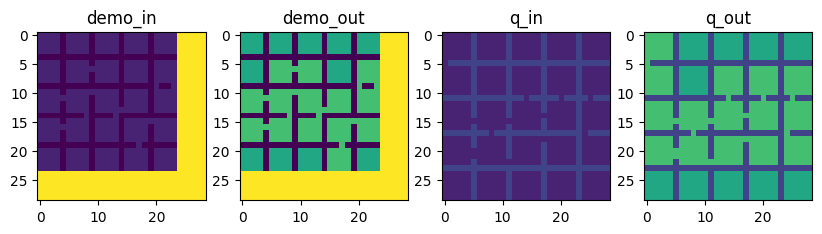

GATE L0: 19434 episodes/s (need >= 50)


In [5]:
ep = sample_episodes(TRAIN_CACHE, TRAIN_TIDS, B=8)
B, ND, Hb, Wb = ep["demo_in"].shape
assert ep["q_in"].shape == (8, Hb, Wb) and ep["demo_mask"].shape == (8, ND)
assert ep["q_out"].max() <= PAD_ID
# augmentation consistency: demo and query of one episode share the color perm (visual spot check)
fig, ax = plt.subplots(1, 4, figsize=(10, 3))
for a, k_ in zip(ax, ("demo_in", "demo_out", "q_in", "q_out")):
    a.imshow(ep[k_][0].cpu() if k_.startswith("q") else ep[k_][0, 0].cpu(), vmin=0, vmax=10)
    a.set_title(k_)
plt.show()
# throughput
torch.cuda.synchronize(); t0 = time.time()
for _ in range(20): sample_episodes(TRAIN_CACHE, TRAIN_TIDS, B=64)
torch.cuda.synchronize()
eps_per_s = 20 * 64 / (time.time() - t0)
print(f"GATE L0: {eps_per_s:.0f} episodes/s (need >= 50)")
assert eps_per_s >= 50

## LeWM modules (SIGReg, AdaLN blocks, MLP)

In [6]:
def modulate(x, shift, scale):
    """AdaLN-zero modulation"""
    return x * (1 + scale) + shift

class SIGReg(nn.Module):
    """Sketch Isotropic Gaussian Regularizer — verbatim from LeWM."""
    def __init__(self, knots=17, num_proj=1024):
        super().__init__()
        self.num_proj = num_proj
        t = torch.linspace(0, 3, knots, dtype=torch.float32)
        dt = 3 / (knots - 1)
        weights = torch.full((knots,), 2 * dt, dtype=torch.float32)
        weights[[0, -1]] = dt
        window = torch.exp(-t.square() / 2.0)
        self.register_buffer("t", t)
        self.register_buffer("phi", window)
        self.register_buffer("weights", weights * window)

    def forward(self, proj):
        # proj: (T, B, D) — Epps-Pulley statistic over random projections
        A = torch.randn(proj.size(-1), self.num_proj, device=proj.device)
        A = A.div_(A.norm(p=2, dim=0))
        x_t = (proj @ A).unsqueeze(-1) * self.t
        err = (x_t.cos().mean(-3) - self.phi).square() + x_t.sin().mean(-3).square()
        return ((err @ self.weights) * proj.size(-2)).mean()

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, hidden_dim), nn.GELU(),
                                 nn.Dropout(dropout), nn.Linear(hidden_dim, dim), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)

class Attention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.0, causal=False):
        super().__init__()
        inner = dim_head * heads
        self.heads, self.scale, self.causal, self.dropout = heads, dim_head ** -0.5, causal, dropout
        self.norm = nn.LayerNorm(dim)
        self.to_qkv = nn.Linear(dim, inner * 3, bias=False)
        self.to_out = nn.Linear(inner, dim)
    def forward(self, x):
        x = self.norm(x)
        q, k, v = (rearrange(t, "b t (h d) -> b h t d", h=self.heads) for t in self.to_qkv(x).chunk(3, -1))
        out = F.scaled_dot_product_attention(q, k, v, dropout_p=self.dropout if self.training else 0.0,
                                             is_causal=self.causal)
        return self.to_out(rearrange(out, "b h t d -> b t (h d)"))

class Block(nn.Module):
    def __init__(self, dim, heads, dim_head, mlp_dim, dropout=0.0):
        super().__init__()
        self.attn = Attention(dim, heads, dim_head, dropout)
        self.mlp = FeedForward(dim, mlp_dim, dropout)
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))

class ConditionalBlock(nn.Module):
    """Transformer block with AdaLN-zero conditioning — from LeWM."""
    def __init__(self, dim, heads, dim_head, mlp_dim, dropout=0.0):
        super().__init__()
        self.attn = Attention(dim, heads, dim_head, dropout)
        self.mlp = FeedForward(dim, mlp_dim, dropout)
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.adaLN_modulation = nn.Sequential(nn.SiLU(), nn.Linear(dim, 6 * dim, bias=True))
        nn.init.constant_(self.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.adaLN_modulation[-1].bias, 0)
    def forward(self, x, c):
        sm, scm, gm, sl, scl, gl = self.adaLN_modulation(c).chunk(6, dim=-1)
        x = x + gm * self.attn(modulate(self.norm1(x), sm, scm))
        return x + gl * self.mlp(modulate(self.norm2(x), sl, scl))

class MLP(nn.Module):
    """LeWM projector MLP (BatchNorm hidden)."""
    def __init__(self, input_dim, hidden_dim, output_dim=None, norm_fn=nn.BatchNorm1d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), norm_fn(hidden_dim), nn.GELU(),
                                 nn.Linear(hidden_dim, output_dim or input_dim))
    def forward(self, x): return self.net(x)

In [7]:
sig = SIGReg().to(DEVICE)
gauss = torch.randn(1, 4096, D, device=DEVICE)
clps  = torch.zeros(1, 4096, D, device=DEVICE)  # fully collapsed embeddings
s_g, s_c = sig(gauss).item(), sig(clps).item()
print(f"sigreg gaussian={s_g:.4f} collapsed={s_c:.4f}")
assert s_g < s_c, "SIGReg must penalize collapsed embeddings more than Gaussian ones"
blk = ConditionalBlock(D, 16, 64, 2048).to(DEVICE)
y = blk(torch.randn(2, K, D, device=DEVICE), torch.randn(2, 1, D, device=DEVICE))
assert y.shape == (2, K, D)
print("OK: modules")

sigreg gaussian=1.0082 collapsed=1646.7869
OK: modules


## Model components: GridEncoder, ProgramEncoder, Predictor

In [8]:
class GridEncoder(nn.Module):
    """Cells -> K register tokens. Linear embed over one-hot so SOFT grids work at inference."""
    def __init__(self, d=D, k=K, depth=6, heads=6):
        super().__init__()
        self.k = k
        self.cell_embed = nn.Linear(VOCAB, d)
        self.pos = nn.Parameter(torch.randn(1, MAX_HW, MAX_HW, d) * 0.02)
        self.registers = nn.Parameter(torch.randn(1, k, d) * 0.02)
        self.blocks = nn.ModuleList([Block(d, heads, d // heads, 4 * d) for _ in range(depth)])
        self.norm = nn.LayerNorm(d)
    def forward(self, g):
        # g: (B,H,W) int grid or (B,H,W,VOCAB) soft one-hot
        if g.dim() == 3: g = F.one_hot(g.long(), VOCAB).float()
        Bz, H, W, _ = g.shape
        x = self.cell_embed(g) + self.pos[:, :H, :W]
        x = torch.cat([self.registers.expand(Bz, -1, -1), rearrange(x, "b h w d -> b (h w) d")], 1)
        for blk in self.blocks: x = blk(x)
        return self.norm(x[:, :self.k])  # (B,K,D)

In [9]:
class ProgramEncoder(nn.Module):
    """Demo pair embeddings -> latent program z (LeWM's 'action')."""
    def __init__(self, d=D, depth=2, heads=6):
        super().__init__()
        self.cls = nn.Parameter(torch.randn(1, 1, d) * 0.02)
        self.seg = nn.Parameter(torch.randn(2, 1, 1, d) * 0.02)  # input/output segment marks
        self.blocks = nn.ModuleList([Block(d, heads, d // heads, 4 * d) for _ in range(depth)])
        self.norm = nn.LayerNorm(d)
    def forward(self, e_in, e_out, mask):
        # e_in/e_out: (B,ND,K,D), mask: (B,ND) -> z: (B,D)
        Bz, ND = e_in.shape[:2]
        x = torch.cat([self.cls.expand(Bz * ND, 1, -1),
                       rearrange(e_in + self.seg[0], "b n k d -> (b n) k d"),
                       rearrange(e_out + self.seg[1], "b n k d -> (b n) k d")], 1)
        for blk in self.blocks: x = blk(x)
        pair = self.norm(x[:, 0]).view(Bz, ND, -1)
        return (pair * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)

class Predictor(nn.Module):
    """AdaLN-zero predictor over register tokens, conditioned on z — LeWM config."""
    def __init__(self, d=D, k=K, depth=6, heads=16, dim_head=64, mlp_dim=2048):
        super().__init__()
        self.pos = nn.Parameter(torch.randn(1, k, d) * 0.02)
        self.blocks = nn.ModuleList([ConditionalBlock(d, heads, dim_head, mlp_dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(d)
    def forward(self, e_x, z):
        x = e_x + self.pos
        c = z.unsqueeze(1)  # broadcast conditioning over the K tokens
        for blk in self.blocks: x = blk(x, c)
        return self.norm(x)

In [10]:
enc_t = GridEncoder().to(DEVICE)
hard = torch.randint(0, VOCAB, (2, 12, 9), device=DEVICE)
soft = F.one_hot(hard.long(), VOCAB).float().requires_grad_(True)
r_h, r_s = enc_t(hard), enc_t(soft)
assert r_h.shape == (2, K, D) and torch.allclose(r_h, r_s, atol=1e-5)
r_s.sum().backward(); assert soft.grad is not None  # gradients reach the grid: planning works
p_t = ProgramEncoder().to(DEVICE)
z_t = p_t(torch.randn(2, 3, K, D, device=DEVICE), torch.randn(2, 3, K, D, device=DEVICE),
          torch.tensor([[1., 1., 0.], [1., 0., 0.]], device=DEVICE))
assert z_t.shape == (2, D)
f_t = Predictor().to(DEVICE)
assert f_t(torch.randn(2, K, D, device=DEVICE), z_t).shape == (2, K, D)
print("OK: components"); del enc_t, p_t, f_t

OK: components


## ARC-LeWM module + two-loss objective — Gate L1

In [11]:
class ARCLeWM(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = GridEncoder()
        self.projector = MLP(D, 2048, D)   # LeWM projector (BatchNorm hidden)
        self.prog = ProgramEncoder()
        self.predictor = Predictor()
        self.pred_proj = MLP(D, 2048, D)   # LeWM pred_proj
    def embed(self, g):
        r = self.enc(g)
        return rearrange(self.projector(rearrange(r, "b k d -> (b k) d")), "(b k) d -> b k d", k=K)

SIG = SIGReg().to(DEVICE)

def episode_loss(model, ep, lam=LAM):
    Bz, ND, H, W = ep["demo_in"].shape
    grids = torch.cat([ep["demo_in"].reshape(-1, H, W), ep["demo_out"].reshape(-1, H, W),
                       ep["q_in"], ep["q_out"]])  # one encoder pass for everything
    e = model.embed(grids)
    e_di, e_do, e_qi, e_qo = e.split([Bz * ND, Bz * ND, Bz, Bz])
    z = model.prog(e_di.view(Bz, ND, K, D), e_do.view(Bz, ND, K, D), ep["demo_mask"])
    pred = model.pred_proj(model.predictor(e_qi, z).reshape(-1, D)).view(Bz, K, D)
    pred_loss = (pred - e_qo).pow(2).mean()          # NO detach on target: end-to-end (LeWM)
    sig_loss = SIG(e.reshape(1, -1, D)) + SIG(z.unsqueeze(0))
    stats = {"pred": pred_loss.item(), "sig": sig_loss.item(),
             "emb_std": e.std(0).mean().item(), "z_std": z.std(0).mean().item()}
    return pred_loss + lam * sig_loss, stats

In [12]:
model = ARCLeWM().to(DEVICE)
print("params (M):", sum(p.numel() for p in model.parameters()) / 1e6)
ep_fix = sample_episodes(TRAIN_CACHE, TRAIN_TIDS, B=8)  # B=8: 16GB VRAM cliff above this (profiled)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
hist = []
for s in range(300):
    with torch.autocast("cuda", dtype=torch.bfloat16):  # bf16 like LeWM (enables flash attention)
        loss, st = episode_loss(model, ep_fix)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step(); hist.append(st)
    if s % 50 == 0: print(s, st)
first, last = hist[0], hist[-1]
print(f"GATE L1: pred {first['pred']:.4f} -> {last['pred']:.4f} | sig {last['sig']:.4f} | "
      f"emb_std {last['emb_std']:.3f} | z_std {last['z_std']:.3f}")
assert last["pred"] < 0.2 * first["pred"], "prediction loss must drop 5x on a fixed batch"
assert last["sig"] > 0, "SIGReg must be active (old notebook bug: silently zero)"
assert last["emb_std"] > 0.1 and last["z_std"] > 0.05, "collapse check"
del opt

params (M): 16.113216


0 {'pred': 0.2171863317489624, 'sig': 368.0, 'emb_std': 0.3359375, 'z_std': 0.7639560699462891}


50 {'pred': 0.1734859198331833, 'sig': 34.0, 'emb_std': 0.79296875, 'z_std': 0.967400312423706}


100 {'pred': 0.07116314768791199, 'sig': 22.0, 'emb_std': 0.79296875, 'z_std': 0.963320255279541}


150 {'pred': 0.04990572854876518, 'sig': 15.4375, 'emb_std': 0.81640625, 'z_std': 0.9282557368278503}


200 {'pred': 0.034379132091999054, 'sig': 12.5, 'emb_std': 0.83984375, 'z_std': 0.918113112449646}


250 {'pred': 0.030177507549524307, 'sig': 10.375, 'emb_std': 0.86328125, 'z_std': 0.9038480520248413}


GATE L1: pred 0.2172 -> 0.0235 | sig 9.7500 | emb_std 0.875 | z_std 0.908
